In [1]:
import starry
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import pymc3.math as pmm
import pymc3_ext as pmx
import exoplanet
from starry_process import StarryProcess, MCMCInterface
from starry_process.math import cho_factor, cho_solve
import starry_process 
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import aesara_theano_fallback.tensor as tt
from theano.tensor.slinalg import cholesky
from corner import corner
import arviz as az
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from tqdm import tqdm
from theano.tensor.random.utils import RandomStream
import scipy.linalg as sl
import scipy.stats as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import lightkurve as lk
import pandas as pd
import seaborn as sns

starry.config.quiet = True
np.random.seed(1)

import warnings

# Ignore all warnings (not recommended, might hide other important warnings)
warnings.filterwarnings("ignore")

# Ignore specific warning by type
warnings.filterwarnings("ignore", message="Cannot construct a scalar test value from a test value with no size")

# Set logging level to ignore these warnings (recommended)
import logging
logger = logging.getLogger("theano.tensor.opt")
logger.setLevel(logging.ERROR)


WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/sabina/.lightkurve/cache. Please move all the files in the legacy directory /Users/sabina/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
import sys
sys.path.insert(1, '../../scripts')

from starry_starry_process import StarryStarryProcess

In [3]:
t = np.arange(0, 90, 2 / 24 / 60) # 90 days of observations with a 2-min cadence

In [6]:
# True parameters & priors
params = {
    "planet.inc": {"truth": 90.},
    "planet.ecc": {"truth": 0.2},
    "planet.Omega": {"truth": 0.0},
    "planet.porb": {"truth": 5.},
    "planet.t0": {"truth": 0.5},
    "planet.r": {"truth": 0.04},
    "planet.m": {"truth":  1e-3},
    "planet.w": {"truth": 60},

    "star.inc": {"truth": 90},
    "star.m": {"truth": 1},
    "star.u1": {"truth": 0.4},
    "star.u2": {"truth": 0.26},
    "star.prot": {"truth": 30.},
    "star.obl": {"truth": -30},
    "star.r": {"truth": 1},

    "gp.a": {"truth": 0.6},
    "gp.b": {"truth": 0.2},
    "gp.r": {"truth": 10},
    "gp.c": {"truth": 0.5},
    "gp.n": {"truth": 3},
}

Text(0.5, 0, 'time [days]')

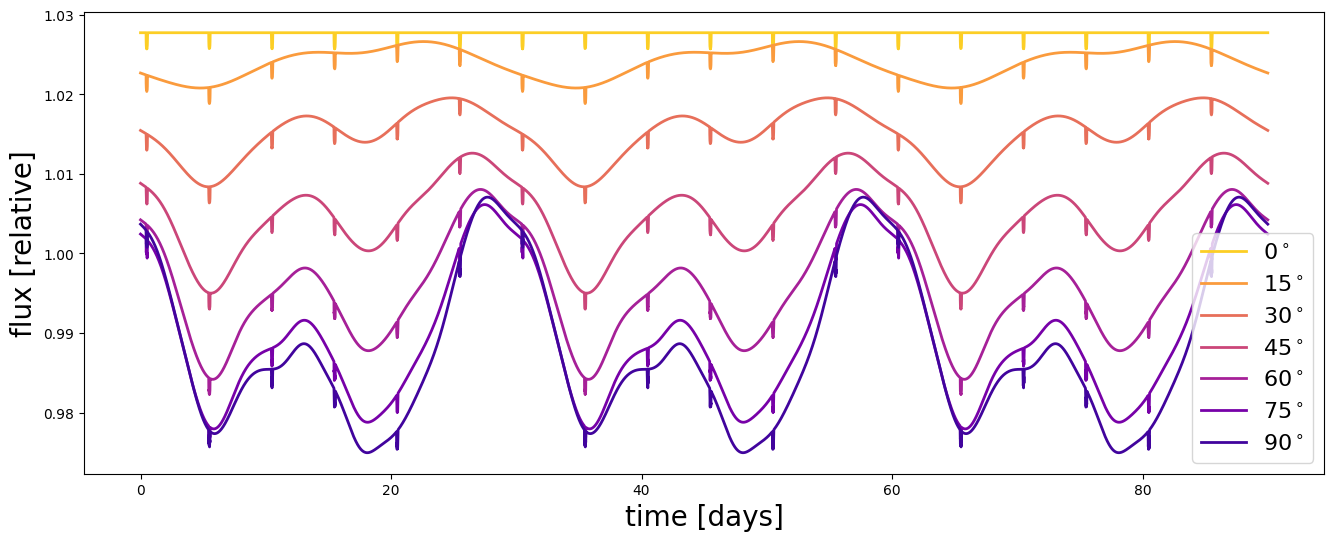

In [ ]:
starry.config.lazy = True
incs = [0,15,30,45,60,75,90]

rng = np.random.default_rng(9878997)
nt = len(t)

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(incs) - 1))

plt.figure(figsize=(16,6))

for k in range(len(incs)):
    map = starry.Map(15, 2)
    map.inc = incs[k]
    map.obl = 0.0
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)
    xo, yo, zo = sys.position(t)
    xo = xo.eval()[1]
    yo = yo.eval()[1]
    zo = zo.eval()[1]
    theta = (360 * t / params["star.prot"]["truth"]) % 360
        
    sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
    y_true = sp.sample_ylm().eval()[0,:]
    y_true[0] = 1.0

    flux_true = sys.design_matrix(t).eval()[:, :-1] @ y_true
    sigma_flux = 1e-4*np.ones_like(flux_true)

    flux_obs = flux_true + sigma_flux*rng.normal(size=nt)

    # ssp = StarryStarryProcess(sys, sp, nt, len(pri.map.y.eval()))

    map[:,:] = y_true
    # map.show(ax=ax[0][k]) 

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)

    sel = np.abs(t) < 1
    plt.plot(t, flux_true, color=color(k), lw=2, label=rf"${incs[k]}^\circ$")
    plt.legend(fontsize=16)

plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.savefig("../figures/inclinations.pdf", bbox_inches="tight", dpi=300)


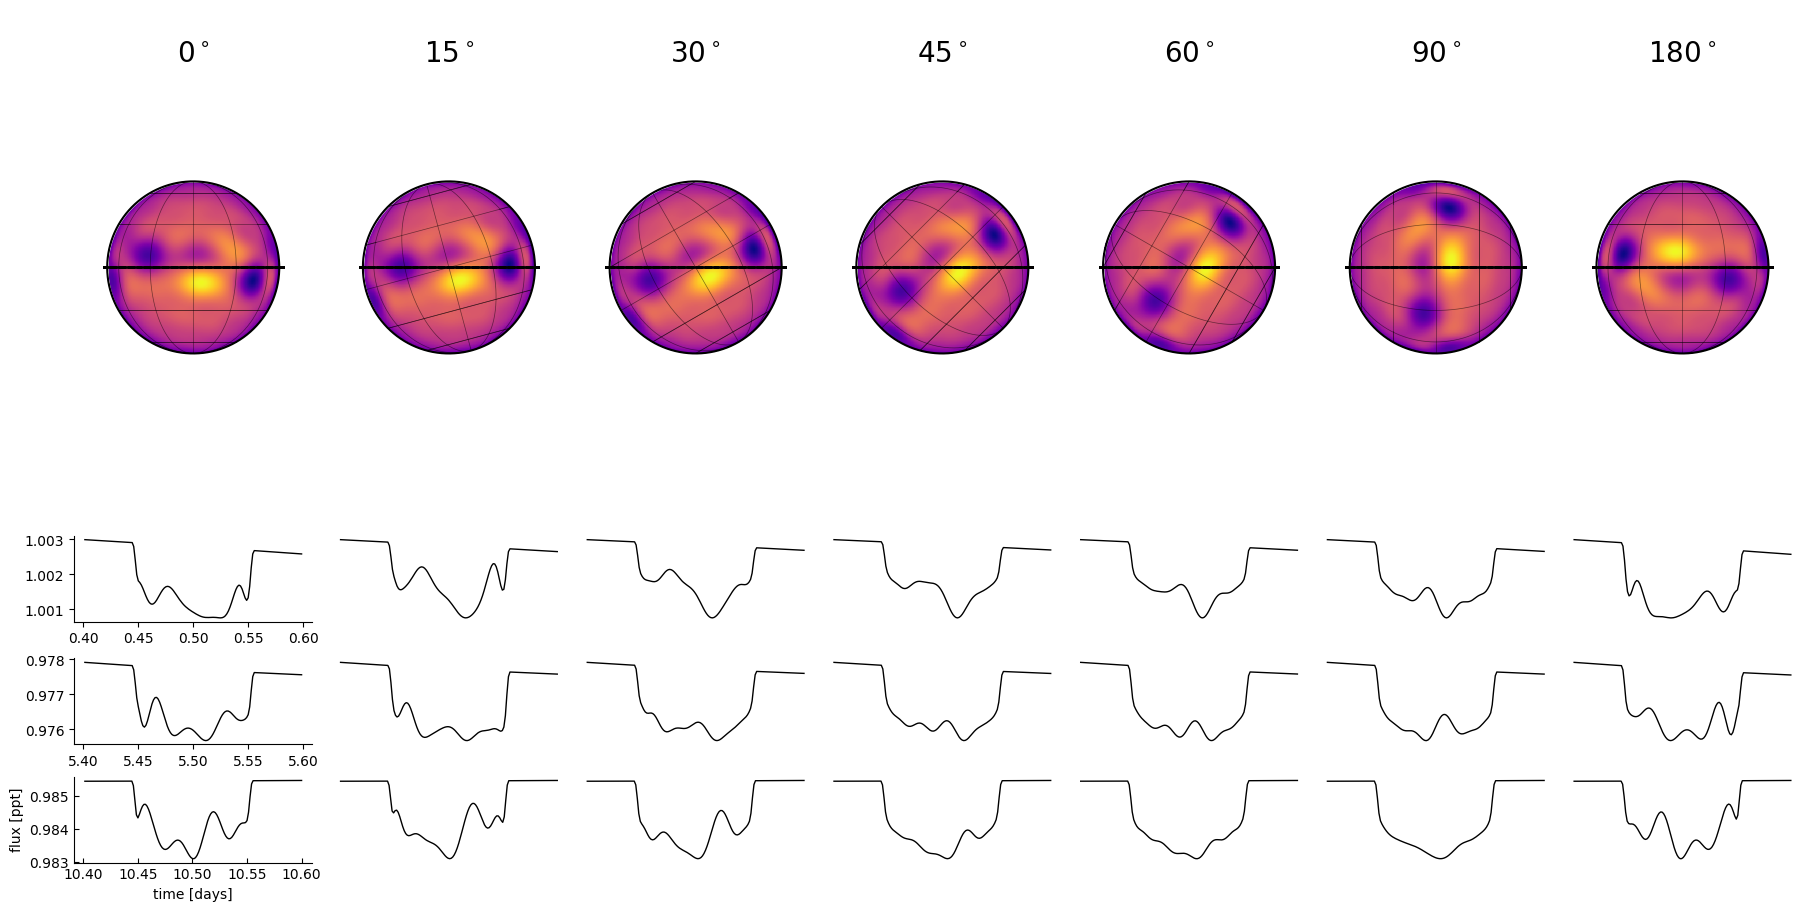

In [11]:
starry.config.lazy = True
obls = [0,15,30,45,60,90,180]

ntransits = int(np.ceil(t[-1] / params['planet.porb']['truth'])) // 6
for n in range(ntransits):
        t0 = 0 + n * params['planet.porb']['truth']
        idx |= ((t > t0 - 0.01) & (t < t0 + 0.01))

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(6) - 1))

fig, ax = plt.subplots(
    # 2+ntransits,
    1+ntransits,
    len(obls),
    figsize=(18, 9),
    gridspec_kw={
        "height_ratios": [3]+[0.5]*ntransits,
    },
    constrained_layout=True,
)

map = starry.Map(15, udeg=2, inc = 90)
sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
y_true = sp.sample_ylm().eval()[0,:]
y_true[0] = 1.0

map[:,:] = y_true

for k in range(len(obls)):
    map.obl = obls[k]
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)

    flux_true = sys.flux(t, total=False)[0].eval()

    map.show(ax=ax[0][k])

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
    ax[0][k].plot(xo[idx], yo[idx], "k.", ms=1);
    ax[0][k].set_aspect(1)
    ax[0][k].set_ylim(-3, 3)

    for i in range(ntransits):

        idx = (t > planet.t0.eval()+i*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+i*planet.porb.eval()+0.1)
        ax[i+1][k].plot(t[idx], flux_true[idx], color='k', lw=1)
    
        if k == 0:
                ax[i+1, k].spines["top"].set_visible(False)
                ax[i+1, k].spines["right"].set_visible(False)
        else:
            ax[i+1, k].axis("off")
        if k == 0 and i==ntransits-1:
                ax[i+1, k].set_xlabel("time [days]", fontsize=10)
                ax[i+1, k].set_ylabel("flux [ppt]", fontsize=10)
                ax[i+1, k].tick_params(direction="in")
            
    # Add annotation above each column
    ax[0, k].text(0.5, 0.9, rf"${obls[k]}^\circ$", transform=ax[0, k].transAxes,
                 fontsize=20, ha='center')

plt.savefig("../figures/obliquities.pdf", bbox_inches="tight", dpi=300)